In [1]:
def sigma(x):
    return 1 / (1 + np.exp(-x))

In [2]:
import numpy as np
import pandas as pd

'''
what fluid are we dealing with?
where is it used, what are its properties?
'''

def generate_dataset(N=10000):


    Q = np.random.uniform(0.1, 10.0, N)     # what should this range be? flow rate
    P = np.random.uniform(0.5, 2.0, N)      #  what should the range be? pressure
    h = np.random.uniform(0.0, 1.0, N)      # what is the optimum height used in filling as a standard? +_ some admissible range

    # critical thresholds
    Pc = 1.2 # look for ref
    hc = 0.5 # look fo ref: idea is that more bubbles are formed from a greater height

    # coefficients (you can tune these)
    alpha1, alpha2, alpha3 = 0.5, 1.0, 0.8
    beta1, beta2, beta3 = 1.2, 0.6, 0.4
    gamma1, gamma2, gamma3, gamma4 = 0.3, 0.7, 0.5, 0.2

    kp, kh, k = 5.0, 5.0, 0.3

    def sigma(x):
        return 1 / (1 + np.exp(-x))

    # -----------------------------
    # Generate outputs
    # -----------------------------
    Bf = (
        alpha1 * Q +
        alpha2 * Q * sigma(kp * (Pc - P)) +
        alpha3 * Q * sigma(kh * (h - hc))
    ) # check for the effects of Q, V, and  h on frequency 

    Bs = (
        beta1 * Q * np.exp(-k * Q) +
        beta2 * sigma(kh * (h - hc)) +
        beta3 * Q * sigma(kh * (h - hc))
    ) # check for the effects of Q, V, and  h on size 

    Bv = (
        gamma1 * sigma(kp * (Pc - P)) +
        gamma2 * Q * sigma(kp * (Pc - P)) +
        gamma3 * Q * sigma(kh * (h - hc)) +
        gamma4 * Q * sigma(Pc - P) * sigma(h - hc)
    ) # check for the effects of Q, V, and  h on velocity


    # Noise depends on how data was captured, look at th plots from the original paper and find some correlation 
    noise_level = 0.05
    Bf += noise_level * np.random.randn(N)
    Bs += noise_level * np.random.randn(N)
    Bv += noise_level * np.random.randn(N)

    # -----------------------------
    # Build dataset
    # -----------------------------
    data = pd.DataFrame({
        "Q": Q,
        "P": P,
        "h": h,
        "Bf": Bf,
        "Bs": Bs,
        "Bv": Bv
    })

    return data

In [12]:
data = generate_dataset()

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# features and targets
X = data[["Q", "P", "h"]].values
y = data[["Bf", "Bs", "Bv"]].values

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale inputs (VERY important for NN)
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# scale outputs (optional buthelpful)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

In [14]:
import torch
import torch.nn as nn

class BubbleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3)   # outputs: Bf, Bs, Bv
        )

    def forward(self, x):
        return self.net(x)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BubbleNet().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

epochs = 200

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_t)
            test_loss = criterion(test_preds, y_test_t)

        print(f"Epoch {epoch}, Train Loss: {loss.item():.4e}, Test Loss: {test_loss.item():.4e}")

Epoch 0, Train Loss: 1.0135e+00, Test Loss: 1.0273e+00
Epoch 20, Train Loss: 7.0662e-01, Test Loss: 7.1079e-01
Epoch 40, Train Loss: 1.9312e-01, Test Loss: 1.8383e-01
Epoch 60, Train Loss: 4.6831e-02, Test Loss: 4.4379e-02
Epoch 80, Train Loss: 2.8884e-02, Test Loss: 2.7578e-02
Epoch 100, Train Loss: 1.9125e-02, Test Loss: 1.8537e-02
Epoch 120, Train Loss: 1.4009e-02, Test Loss: 1.3551e-02
Epoch 140, Train Loss: 1.1061e-02, Test Loss: 1.0727e-02
Epoch 160, Train Loss: 9.1142e-03, Test Loss: 8.8358e-03
Epoch 180, Train Loss: 7.7003e-03, Test Loss: 7.4370e-03


In [16]:
model.eval()
with torch.no_grad():
    preds = model(X_test_t).cpu().numpy()

# inverse scaling
preds = scaler_y.inverse_transform(preds)
y_true = scaler_y.inverse_transform(y_test)

# simple error
mse = np.mean((preds - y_true)**2)
print("Final MSE:", mse)


'''
Significnce of this output is as follows:
if we had a lab we would have obtained this data set directly from experimentation. We would not know the relations between iput and output parameters.
Post data generatation, we are using a NN to approximate the same functions that we generated data from 
'''

Final MSE: 0.03750397144622848


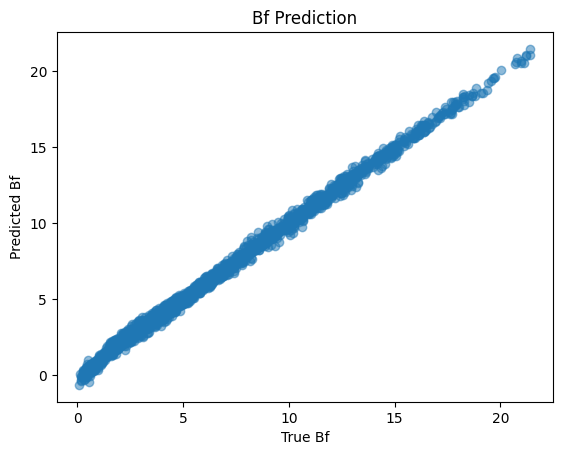

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_true[:, 0], preds[:, 0], alpha=0.5)
plt.xlabel("True Bf")
plt.ylabel("Predicted Bf")
plt.title("Bf Prediction")
plt.show()

# predicting Bf reasonably well trust _/\_

In [18]:
def objective(outputs):
    Bf, Bs, Bv = outputs
    # v v v imp question, when we say we are trying to optimise paramters, what are we trying to optimise for? what is the objective function in our case?

In [19]:
import torch

# grafient descending over the obejctive to find optimal input parameters using ADAMs optimiser
x = torch.tensor([[1.0, 1.0, 0.5]], dtype=torch.float32, requires_grad=True)

optimizer = torch.optim.Adam([x], lr=0.01)

for i in range(500):

    optimizer.zero_grad()

    pred = model(x)   # forward pass
    loss = pred.sum() # minimize bubbles

    loss.backward()
    optimizer.step()

    # optional: clamp to valid range
    with torch.no_grad():
        x[:, 0].clamp_(0.1, 10.0)   # Q
        x[:, 1].clamp_(0.5, 2.0)    # P
        x[:, 2].clamp_(0.0, 1.0)    # h

    if i % 50 == 0:
        print(f"Step {i}, loss = {loss.item():.4f}, x = {x.detach().numpy()}")

print("Optimal parameters:", x.detach().numpy())

Step 0, loss = 1.5914, x = [[0.99 1.01 0.49]]
Step 50, loss = -0.3805, x = [[0.5282968 1.4481554 0.       ]]
Step 100, loss = -1.3068, x = [[0.1       1.9082713 0.       ]]
Step 150, loss = -1.3979, x = [[0.1 2.  0. ]]
Step 200, loss = -1.3979, x = [[0.1 2.  0. ]]
Step 250, loss = -1.3979, x = [[0.1 2.  0. ]]
Step 300, loss = -1.3979, x = [[0.1 2.  0. ]]
Step 350, loss = -1.3979, x = [[0.1 2.  0. ]]
Step 400, loss = -1.3979, x = [[0.1 2.  0. ]]
Step 450, loss = -1.3979, x = [[0.1 2.  0. ]]
Optimal parameters: [[0.1 2.  0. ]]
